In [1]:
%pip install -U tensorflow-datasets importlib-resources

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import importlib_resources

print("TensorFlow:", tf.__version__)
print("TFDS:", tfds.__version__)
print("Everything OK")

TensorFlow: 2.21.0
TFDS: 4.9.10
Everything OK


In [3]:
import tensorflow_datasets as tfds

dataset, info = tfds.load(
    "food101",
    split="train",
    with_info=True,
    as_supervised=True,
    download=True
)

print("Dataset loaded successfully!")
print("Number of classes:", info.features["label"].num_classes)

Dataset loaded successfully!
Number of classes: 101


In [4]:
classes = info.features["label"].names

print("Number of classes:", len(classes))

for i, name in enumerate(classes):
    print(i, name)

Number of classes: 101
0 apple_pie
1 baby_back_ribs
2 baklava
3 beef_carpaccio
4 beef_tartare
5 beet_salad
6 beignets
7 bibimbap
8 bread_pudding
9 breakfast_burrito
10 bruschetta
11 caesar_salad
12 cannoli
13 caprese_salad
14 carrot_cake
15 ceviche
16 cheesecake
17 cheese_plate
18 chicken_curry
19 chicken_quesadilla
20 chicken_wings
21 chocolate_cake
22 chocolate_mousse
23 churros
24 clam_chowder
25 club_sandwich
26 crab_cakes
27 creme_brulee
28 croque_madame
29 cup_cakes
30 deviled_eggs
31 donuts
32 dumplings
33 edamame
34 eggs_benedict
35 escargots
36 falafel
37 filet_mignon
38 fish_and_chips
39 foie_gras
40 french_fries
41 french_onion_soup
42 french_toast
43 fried_calamari
44 fried_rice
45 frozen_yogurt
46 garlic_bread
47 gnocchi
48 greek_salad
49 grilled_cheese_sandwich
50 grilled_salmon
51 guacamole
52 gyoza
53 hamburger
54 hot_and_sour_soup
55 hot_dog
56 huevos_rancheros
57 hummus
58 ice_cream
59 lasagna
60 lobster_bisque
61 lobster_roll_sandwich
62 macaroni_and_cheese
63 macaro

In [5]:
print(info)

tfds.core.DatasetInfo(
    name='food101',
    full_name='food101/2.0.0',
    description="""
    This dataset consists of 101 food categories, with 101'000 images. For each class, 250 manually reviewed test images are provided as well as 750 training images. On purpose, the training images were not cleaned, and thus still contain some amount of noise. This comes mostly in the form of intense colors and sometimes wrong labels. All images were rescaled to have a maximum side length of 512 pixels.
    """,
    homepage='https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/',
    data_dir='C:\\Users\\ravik\\tensorflow_datasets\\food101\\2.0.0',
    file_format=tfrecord,
    download_size=4.65 GiB,
    dataset_size=4.77 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=Fa

In [6]:
print("Train examples:", info.splits["train"].num_examples)

Train examples: 75750


Image shape: (512, 512, 3)
Food: huevos_rancheros


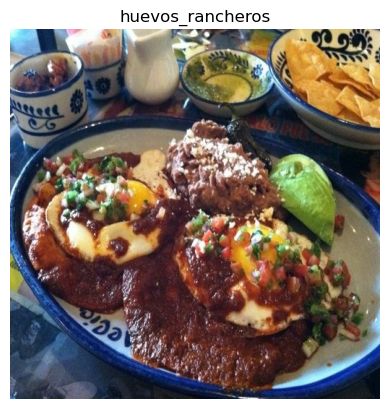

In [7]:
import matplotlib.pyplot as plt

for image, label in dataset.take(1):
    print("Image shape:", image.shape)
    print("Food:", classes[label.numpy()])

    plt.imshow(image)
    plt.title(classes[label.numpy()])
    plt.axis("off")
    plt.show()

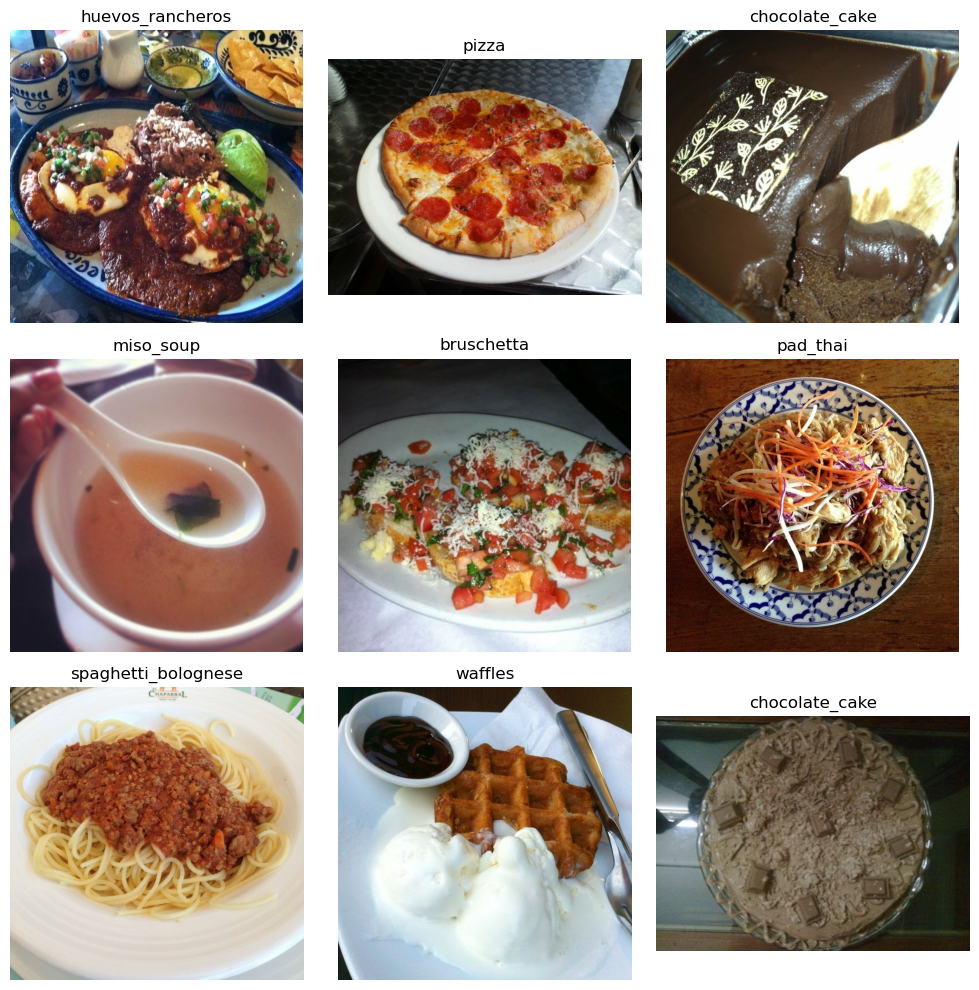

In [8]:
plt.figure(figsize=(10, 10))

for i, (image, label) in enumerate(dataset.take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(classes[label.numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
for image, label in dataset.take(5):
    print(image.shape)

(512, 512, 3)
(384, 512, 3)
(512, 512, 3)
(512, 512, 3)
(512, 512, 3)


In [10]:
classes = info.features["label"].names

In [11]:
selected_classes = [
    "samosa",
    "fried_rice",
    "pizza",
    "hamburger",
    "omelette",
    "french_fries",
    "pancakes",
    "lasagna",
    "sushi",
    "tacos"
]

In [12]:
classes = info.features["label"].names

In [13]:
selected_labels = [
    classes.index(name)
    for name in selected_classes
]

print(selected_labels)

[85, 44, 76, 53, 67, 40, 72, 59, 95, 96]


In [14]:
def filter_classes(image, label):
    return tf.reduce_any(
        tf.equal(label, selected_labels)
    )

In [15]:
filtered_dataset = dataset.filter(filter_classes)

In [16]:
found_labels = set()

for image, label in filtered_dataset.take(100):
    found_labels.add(label.numpy())

print(found_labels)

{np.int64(96), np.int64(67), np.int64(72), np.int64(40), np.int64(76), np.int64(44), np.int64(53), np.int64(85), np.int64(59), np.int64(95)}


In [17]:
found_labels = set()

for image, label in filtered_dataset.take(1000):
    found_labels.add(label.numpy())

for label in sorted(found_labels):
    print(label, classes[label])

40 french_fries
44 fried_rice
53 hamburger
59 lasagna
67 omelette
72 pancakes
76 pizza
85 samosa
95 sushi
96 tacos


In [18]:
count = 0

for image, label in filtered_dataset:
    count += 1

print("Total selected images:", count)

Total selected images: 7500


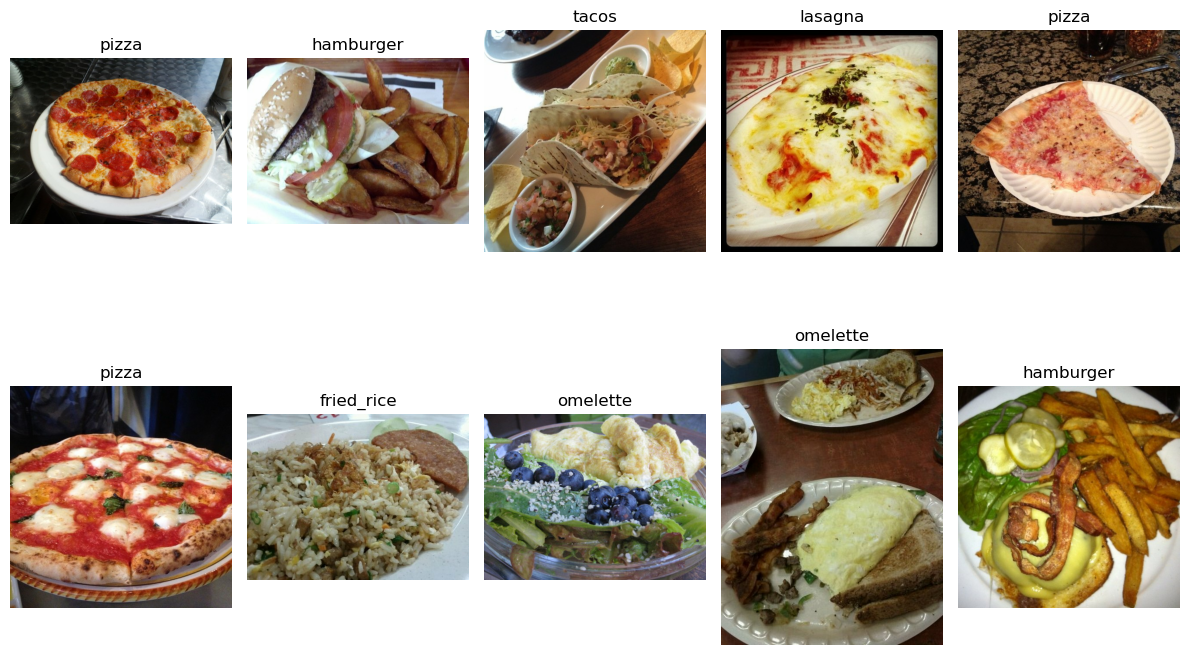

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i, (image, label) in enumerate(filtered_dataset.take(10)):

    plt.subplot(2, 5, i + 1)

    plt.imshow(image)
    plt.title(classes[label.numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
def preprocess_image(image, label):

    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32)
    image = image / 255.0

    return image, label

In [21]:
processed_dataset = filtered_dataset.map(
    preprocess_image
)

In [22]:
processed_dataset = filtered_dataset.map(
    preprocess_image
)

Shape: (224, 224, 3)
Minimum: 0.0
Maximum: 1.0
Food: pizza


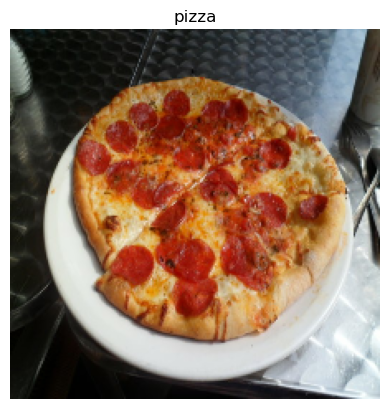

In [23]:
for image, label in processed_dataset.take(1):

    print("Shape:", image.shape)
    print("Minimum:", tf.reduce_min(image).numpy())
    print("Maximum:", tf.reduce_max(image).numpy())
    print("Food:", classes[label.numpy()])

    plt.imshow(image)
    plt.title(classes[label.numpy()])
    plt.axis("off")
    plt.show()

In [24]:
selected_classes = [
    "samosa",
    "fried_rice",
    "pizza",
    "hamburger",
    "omelette",
    "french_fries",
    "pancakes",
    "lasagna",
    "sushi",
    "tacos"
]

In [25]:
label_mapping = {
    classes.index(name): i
    for i, name in enumerate(selected_classes)
}

print(label_mapping)

{85: 0, 44: 1, 76: 2, 53: 3, 67: 4, 40: 5, 72: 6, 59: 7, 95: 8, 96: 9}


In [26]:
keys = tf.constant(list(label_mapping.keys()), dtype=tf.int64)
values = tf.constant(list(label_mapping.values()), dtype=tf.int64)

table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(keys, values),
    default_value=-1
)

In [27]:
def remap_label(image, label):
    new_label = table.lookup(tf.cast(label, tf.int64))
    return image, new_label

In [28]:
remapped_dataset = filtered_dataset.map(remap_label)

In [29]:
for image, label in remapped_dataset.take(10):
    print(
        "New label:",
        label.numpy(),
        "Food:",
        selected_classes[label.numpy()]
    )

New label: 2 Food: pizza
New label: 3 Food: hamburger
New label: 9 Food: tacos
New label: 7 Food: lasagna
New label: 2 Food: pizza
New label: 2 Food: pizza
New label: 1 Food: fried_rice
New label: 4 Food: omelette
New label: 4 Food: omelette
New label: 3 Food: hamburger


In [30]:
def preprocess_image(image, label):

    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32)
    image = image / 255.0

    return image, label

In [31]:
remapped_dataset = filtered_dataset.map(remap_label)

In [32]:
processed_dataset = remapped_dataset.map(preprocess_image)

In [33]:
for image, label in processed_dataset.take(1):

    print("Image shape:", image.shape)
    print("Pixel min:", tf.reduce_min(image).numpy())
    print("Pixel max:", tf.reduce_max(image).numpy())
    print("Label:", label.numpy())
    print("Food:", selected_classes[label.numpy()])

Image shape: (224, 224, 3)
Pixel min: 0.0
Pixel max: 1.0
Label: 2
Food: pizza


In [34]:
for image, label in processed_dataset.take(1):

    print("Image shape:", image.shape)
    print("Pixel min:", tf.reduce_min(image).numpy())
    print("Pixel max:", tf.reduce_max(image).numpy())
    print("Label:", label.numpy())
    print("Food:", selected_classes[label.numpy()])

Image shape: (224, 224, 3)
Pixel min: 0.0
Pixel max: 1.0
Label: 2
Food: pizza


In [35]:
count = 0

for image, label in processed_dataset:
    count += 1

print("Total images:", count)

Total images: 7500


In [36]:
train_size = int(count * 0.8)
val_size = int(count * 0.1)
test_size = count - train_size - val_size

print("Train:", train_size)
print("Validation:", val_size)
print("Test:", test_size)

Train: 6000
Validation: 750
Test: 750


In [37]:
train_size = int(count * 0.8)
val_size = int(count * 0.1)
test_size = count - train_size - val_size

print("Train:", train_size)
print("Validation:", val_size)
print("Test:", test_size)

Train: 6000
Validation: 750
Test: 750


In [38]:
shuffled_dataset = processed_dataset.shuffle(
    buffer_size=1000,
    seed=42,
    reshuffle_each_iteration=False
)

In [39]:
train_dataset = shuffled_dataset.take(train_size)

remaining_dataset = shuffled_dataset.skip(train_size)

val_dataset = remaining_dataset.take(val_size)

test_dataset = remaining_dataset.skip(val_size)

In [40]:
def count_dataset(dataset):
    count = 0

    for _ in dataset:
        count += 1

    return count

In [41]:
print("Train:", count_dataset(train_dataset))
print("Validation:", count_dataset(val_dataset))
print("Test:", count_dataset(test_dataset))

Train: 6000
Validation: 750
Test: 750


In [42]:
batch_size = 32

train_dataset = train_dataset.batch(batch_size)
val_dataset = val_dataset.batch(batch_size)
test_dataset = test_dataset.batch(batch_size)

In [43]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [44]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [45]:
for images, labels in train_dataset.take(1):

    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


In [46]:
for images, labels in train_dataset.take(1):

    print(labels.numpy())

[5 0 8 0 7 6 3 7 3 9 7 5 4 8 5 8 9 3 2 6 7 4 7 6 0 6 7 2 2 1 2 4]


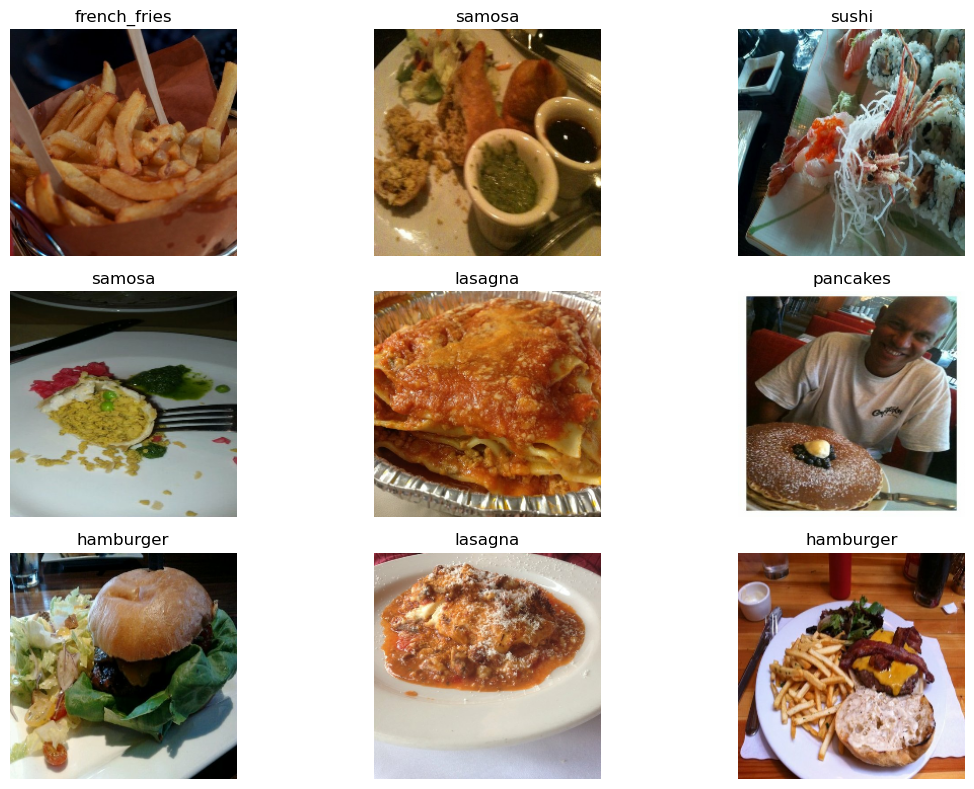

In [47]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):

    plt.figure(figsize=(12, 8))

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i])

        label = labels[i].numpy()

        plt.title(selected_classes[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [48]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


In [49]:
tf.keras.applications.mobilenet_v2.preprocess_input

<function keras.src.applications.mobilenet_v2.preprocess_input(x, data_format=None)>

In [50]:
def mobilenet_preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

In [51]:
def mobilenet_preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

In [52]:
total_count = 0

for _ in remapped_dataset:
    total_count += 1

print("Total selected images:", total_count)

Total selected images: 7500


In [53]:
train_size = int(total_count * 0.8)
val_size = int(total_count * 0.1)
test_size = total_count - train_size - val_size

print("Train:", train_size)
print("Validation:", val_size)
print("Test:", test_size)

Train: 6000
Validation: 750
Test: 750


In [55]:
def mobilenet_preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

In [56]:
mobilenet_dataset = remapped_dataset.map(
    mobilenet_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [57]:
shuffled_dataset = mobilenet_dataset.shuffle(
    buffer_size=1000,
    seed=42,
    reshuffle_each_iteration=False
)

In [58]:
train_dataset = shuffled_dataset.take(train_size)

remaining_dataset = shuffled_dataset.skip(train_size)

val_dataset = remaining_dataset.take(val_size)

test_dataset = remaining_dataset.skip(val_size)

In [59]:
batch_size = 32

train_dataset = train_dataset.batch(batch_size)
val_dataset = val_dataset.batch(batch_size)
test_dataset = test_dataset.batch(batch_size)

In [61]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [62]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Pixel minimum:", tf.reduce_min(images).numpy())
    print("Pixel maximum:", tf.reduce_max(images).numpy())

InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Cannot batch tensors with different shapes in component 0. First element had shape [512,512,3] and element 1 had shape [384,512,3]. [Op:IteratorGetNext] name: 

In [63]:
for image, label in remapped_dataset.take(1):
    print("Image shape:", image.shape)
    print("Image dtype:", image.dtype)
    print("Label:", label.numpy())

Image shape: (384, 512, 3)
Image dtype: <dtype: 'uint8'>
Label: 2


In [64]:
def mobilenet_preprocess(image, label):

    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32)

    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label

In [65]:
mobilenet_dataset = remapped_dataset.map(
    mobilenet_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [66]:
for image, label in mobilenet_dataset.take(1):
    print("Image shape:", image.shape)
    print("Label:", label.numpy())
    print("Min:", tf.reduce_min(image).numpy())
    print("Max:", tf.reduce_max(image).numpy())

Image shape: (224, 224, 3)
Label: 2
Min: -1.0
Max: 1.0


In [67]:
shuffled_dataset = mobilenet_dataset.shuffle(
    buffer_size=1000,
    seed=42,
    reshuffle_each_iteration=False
)

train_dataset = shuffled_dataset.take(train_size)

remaining_dataset = shuffled_dataset.skip(train_size)

val_dataset = remaining_dataset.take(val_size)

test_dataset = remaining_dataset.skip(val_size)

In [68]:
batch_size = 32

train_dataset = train_dataset.batch(batch_size)
val_dataset = val_dataset.batch(batch_size)
test_dataset = test_dataset.batch(batch_size)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [69]:
for images, labels in train_dataset.take(1):
    print("Images:", images.shape)
    print("Labels:", labels.shape)

Images: (32, 224, 224, 3)
Labels: (32,)


In [70]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [71]:
base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [72]:
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [77]:
inputs = keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    10,
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │          12,810 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 2,236,682 (8.53 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [78]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [79]:
print("Model compiled successfully!")

Model compiled successfully!


In [84]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "food_classifier_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [80]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5


C:\Users\ravik\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


    188/Unknown 799s 4s/step - accuracy: 0.6802 - loss: 1.0249

C:\Users\ravik\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


188/188 ━━━━━━━━━━━━━━━━━━━━ 871s 4s/step - accuracy: 0.6802 - loss: 1.0249 - val_accuracy: 0.4280 - val_loss: 5.3770
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 783s 4s/step - accuracy: 0.8145 - loss: 0.5753 - val_accuracy: 0.2160 - val_loss: 10.6233
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 771s 4s/step - accuracy: 0.8692 - loss: 0.3885 - val_accuracy: 0.1987 - val_loss: 16.2953
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 752s 4s/step - accuracy: 0.8807 - loss: 0.3555 - val_accuracy: 0.1173 - val_loss: 9.3855
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 703s 4s/step - accuracy: 0.9058 - loss: 0.2941 - val_accuracy: 0.2653 - val_loss: 12.1402


In [85]:
model.save("food_classifier_final.keras")
print("Final model saved successfully!")

Final model saved successfully!


In [86]:
import os

print("Best model exists:", os.path.exists("food_classifier_best.keras"))
print("Final model exists:", os.path.exists("food_classifier_final.keras"))

Best model exists: False
Final model exists: True


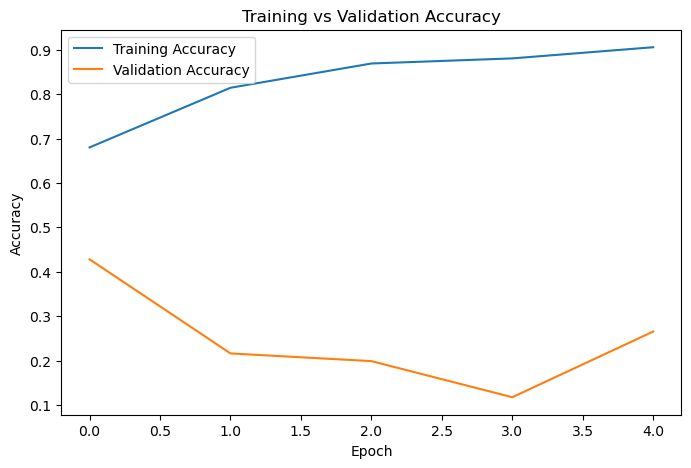

In [81]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

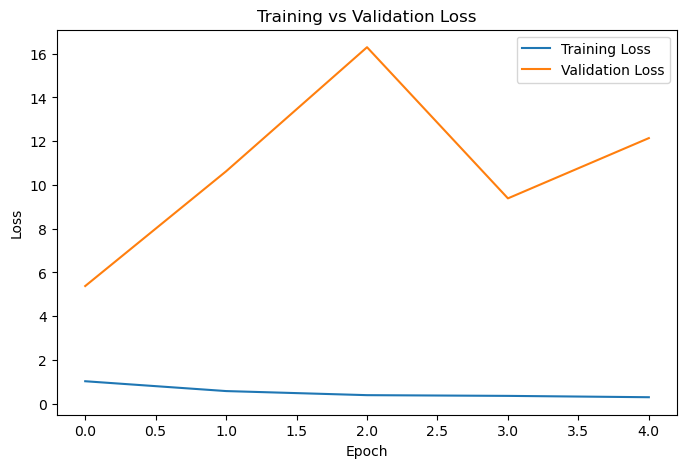

In [82]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [83]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

24/24 ━━━━━━━━━━━━━━━━━━━━ 60s 618ms/step - accuracy: 0.2733 - loss: 11.8543
Test Loss: 11.854320526123047
Test Accuracy: 0.273333340883255


In [87]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(
    y_true,
    y_pred,
    target_names=selected_classes
))

              precision    recall  f1-score   support

      samosa       1.00      0.06      0.12        65
  fried_rice       0.36      0.77      0.49        73
       pizza       0.00      0.00      0.00        73
   hamburger       0.20      0.01      0.02        87
    omelette       0.15      0.90      0.26        72
french_fries       1.00      0.17      0.30        86
    pancakes       0.44      0.63      0.52        87
     lasagna       0.00      0.00      0.00        62
       sushi       0.90      0.12      0.22        72
       tacos       0.00      0.00      0.00        73

    accuracy                           0.27       750
   macro avg       0.40      0.27      0.19       750
weighted avg       0.41      0.27      0.20       750



C:\Users\ravik\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ravik\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ravik\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


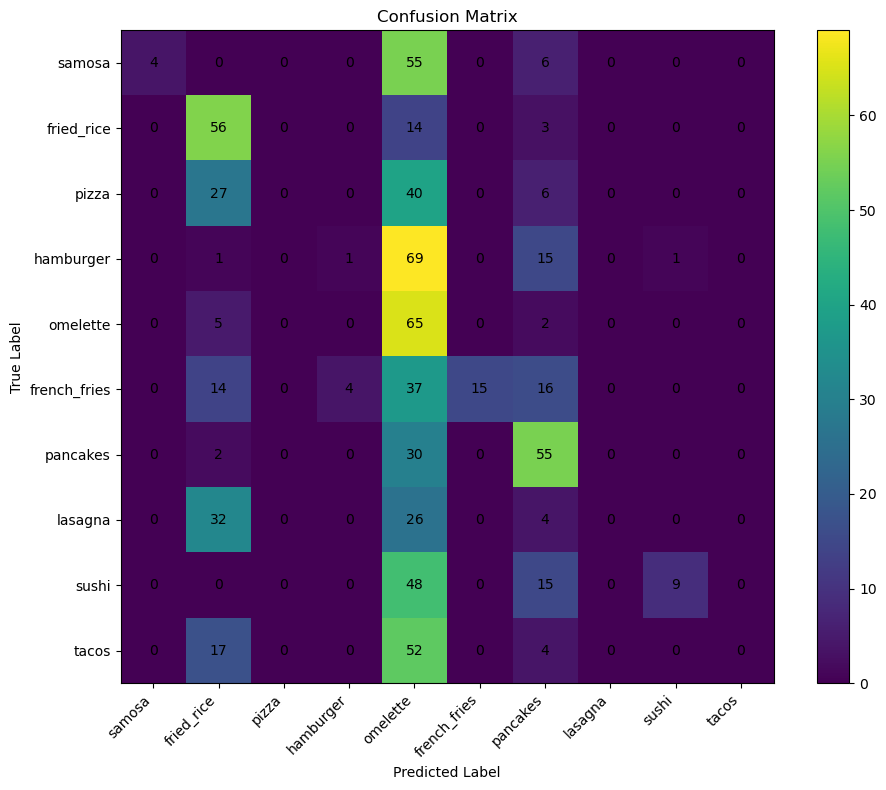

In [88]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(selected_classes)),
    selected_classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(selected_classes)),
    selected_classes
)

plt.colorbar()

for i in range(len(selected_classes)):
    for j in range(len(selected_classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [89]:
from PIL import Image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Path of your image
image_path = ""

# Load image
image = Image.open(image_path).convert("RGB")

# Resize
image_resized = image.resize((224, 224))

# Convert to NumPy array
image_array = np.array(image_resized, dtype=np.float32)

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# MobileNetV2 preprocessing
image_array = tf.keras.applications.mobilenet_v2.preprocess_input(
    image_array
)

# Prediction
predictions = model.predict(image_array, verbose=0)

# Get predicted class
predicted_index = np.argmax(predictions[0])
predicted_food = selected_classes[predicted_index]

# Confidence
confidence = predictions[0][predicted_index] * 100

print("Predicted Food:", predicted_food)
print("Confidence:", f"{confidence:.2f}%")

FileNotFoundError: [Errno 2] No such file or directory: ''

In [90]:
from PIL import Image
import numpy as np
import tensorflow as tf

# Image path
image_path = "D:\Downloads\images (13).jpeg"

# Load image
image = Image.open(image_path).convert("RGB")

# Resize
image_resized = image.resize((224, 224))

# Convert to NumPy
image_array = np.array(image_resized, dtype=np.float32)

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# MobileNetV2 preprocessing
image_array = tf.keras.applications.mobilenet_v2.preprocess_input(
    image_array
)

# Prediction
predictions = model.predict(image_array, verbose=0)

# Highest probability class
predicted_index = np.argmax(predictions[0])
predicted_food = selected_classes[predicted_index]

# Confidence
confidence = predictions[0][predicted_index] * 100

print("Predicted Food:", predicted_food)
print("Confidence:", f"{confidence:.2f}%")

Predicted Food: omelette
Confidence: 68.72%


In [ ]:
from PIL import Image
import numpy as np
import tensorflow as tf

# Image path
image_path = r"D:\Downloads\images (12).jpeg"

# Load image
image = Image.open(image_path).convert("RGB")

# Resize
image_resized = image.resize((224, 224))

# Convert to NumPy
image_array = np.array(image_resized, dtype=np.float32)

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# MobileNetV2 preprocessing
image_array = tf.keras.applications.mobilenet_v2.preprocess_input(
    image_array
)

# Prediction
predictions = model.predict(image_array, verbose=0)

# Highest probability class
predicted_index = np.argmax(predictions[0])
predicted_food = selected_classes[predicted_index]

# Confidence
confidence = predictions[0][predicted_index] * 100

print("Predicted Food:", predicted_food)
print("Confidence:", f"{confidence:.2f}%")

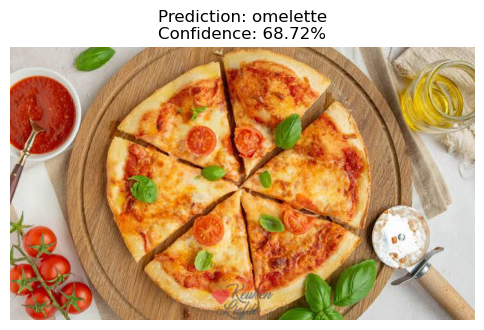

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_food}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()

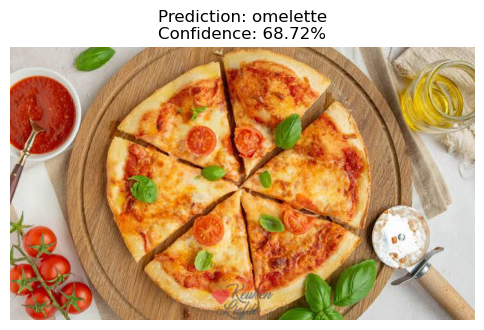

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_food}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()

In [93]:
import pandas as pd

nutrition_data = {
    "food": [
        "samosa",
        "fried_rice",
        "pizza",
        "hamburger",
        "omelette",
        "french_fries",
        "pancakes",
        "lasagna",
        "sushi",
        "tacos"
    ],
    "calories": [
        262,
        163,
        266,
        295,
        154,
        312,
        227,
        135,
        130,
        226
    ],
    "protein": [
        5.0,
        3.0,
        11.0,
        17.0,
        11.0,
        3.4,
        6.0,
        7.0,
        6.0,
        9.0
    ],
    "carbs": [
        32.0,
        25.0,
        33.0,
        24.0,
        1.0,
        41.0,
        28.0,
        18.0,
        28.0,
        18.0
    ],
    "fat": [
        12.0,
        6.0,
        10.0,
        18.0,
        11.0,
        15.0,
        9.0,
        5.0,
        1.0,
        12.0
    ]
}

nutrition_df = pd.DataFrame(nutrition_data)

print(nutrition_df)

           food  calories  protein  carbs   fat
0        samosa       262      5.0   32.0  12.0
1    fried_rice       163      3.0   25.0   6.0
2         pizza       266     11.0   33.0  10.0
3     hamburger       295     17.0   24.0  18.0
4      omelette       154     11.0    1.0  11.0
5  french_fries       312      3.4   41.0  15.0
6      pancakes       227      6.0   28.0   9.0
7       lasagna       135      7.0   18.0   5.0
8         sushi       130      6.0   28.0   1.0
9         tacos       226      9.0   18.0  12.0


In [94]:
predicted_food = "pizza"

food_info = nutrition_df[
    nutrition_df["food"] == predicted_food
].iloc[0]

print("Food:", predicted_food)
print("Calories:", food_info["calories"], "kcal")
print("Protein:", food_info["protein"], "g")
print("Carbohydrates:", food_info["carbs"], "g")
print("Fat:", food_info["fat"], "g")

Food: pizza
Calories: 266 kcal
Protein: 11.0 g
Carbohydrates: 33.0 g
Fat: 10.0 g


In [95]:
def predict_food_with_nutrition(image_path):

    # 1. Load image
    image = Image.open(image_path).convert("RGB")

    # 2. Resize
    image_resized = image.resize((224, 224))

    # 3. Convert to NumPy
    image_array = np.array(image_resized, dtype=np.float32)

    # 4. Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # 5. MobileNetV2 preprocessing
    image_array = tf.keras.applications.mobilenet_v2.preprocess_input(
        image_array
    )

    # 6. Model prediction
    predictions = model.predict(image_array, verbose=0)

    # 7. Get predicted class
    predicted_index = np.argmax(predictions[0])
    predicted_food = selected_classes[predicted_index]

    # 8. Confidence
    confidence = predictions[0][predicted_index] * 100

    # 9. Nutrition lookup
    food_info = nutrition_df[
        nutrition_df["food"] == predicted_food
    ].iloc[0]

    # 10. Display result
    print("================================")
    print("       FOOD PREDICTION")
    print("================================")
    print("Food:", predicted_food)
    print("Confidence:", f"{confidence:.2f}%")
    print()
    print("Nutrition:")
    print("Calories:", food_info["calories"], "kcal")
    print("Protein:", food_info["protein"], "g")
    print("Carbohydrates:", food_info["carbs"], "g")
    print("Fat:", food_info["fat"], "g")
    print("================================")

In [96]:
image_path = r"D:\Downloads\images(13).jpeg"

predict_food_with_nutrition(image_path)

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Downloads\\images(13).jpeg'

In [97]:
image_path = r"D:\Downloads\images (13).jpeg"

predict_food_with_nutrition(image_path)

       FOOD PREDICTION
Food: omelette
Confidence: 68.72%

Nutrition:
Calories: 154 kcal
Protein: 11.0 g
Carbohydrates: 1.0 g
Fat: 11.0 g


In [98]:
from PIL import Image
import numpy as np
import tensorflow as tf

In [99]:
image_path = r"D:\Downloads\images (13).jpeg"

predict_food_with_nutrition(image_path)

       FOOD PREDICTION
Food: omelette
Confidence: 68.72%

Nutrition:
Calories: 154 kcal
Protein: 11.0 g
Carbohydrates: 1.0 g
Fat: 11.0 g


In [100]:
import shutil

shutil.copy2(
    "food_classifier_final.keras",
    "food_classifier_final_backup.keras"
)

print("Backup created successfully!")

Backup created successfully!


In [101]:
import os

print("Final:", os.path.exists("food_classifier_final.keras"))
print("Backup:", os.path.exists("food_classifier_final_backup.keras"))

Final: True
Backup: True


In [102]:
import shutil
import os

shutil.copy2(
    "food_classifier_final.keras",
    "food_classifier_final_backup.keras"
)

print("Backup:", os.path.exists("food_classifier_final_backup.keras"))

Backup: True


In [103]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "food_classifier_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [ ]:
print("Train batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

In [ ]:
print("Train batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

In [ ]:
for images, labels in train_dataset.take(1):
    print("Train images:", images.shape)
    print("Train labels:", labels.shape)
    print("Label range:", labels.numpy().min(), "to", labels.numpy().max())

In [ ]:
for images, labels in val_dataset.take(1):
    print("Val images:", images.shape)
    print("Val labels:", labels.shape)
    print("Label range:", labels.numpy().min(), "to", labels.numpy().max())

In [105]:
print("Kernel is working")
print("Model:", model is not None)
print("Train dataset:", train_dataset)
print("Validation dataset:", val_dataset)
print("Test dataset:", test_dataset)

Kernel is working
Model: True
Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


In [106]:
for images, labels in train_dataset.take(1):
    print("Train images:", images.shape)
    print("Train labels:", labels.shape)
    print("Train label range:", labels.numpy().min(), "to", labels.numpy().max())
    

Train images: (32, 224, 224, 3)
Train labels: (32,)
Train label range: 0 to 9


In [107]:
for images, labels in val_dataset.take(1):
    print("Val images:", images.shape)
    print("Val labels:", labels.shape)
    print("Val label range:", labels.numpy().min(), "to", labels.numpy().max())

Val images: (32, 224, 224, 3)
Val labels: (32,)
Val label range: 0 to 9


In [108]:
# Clean MobileNetV2 dataset pipeline

mobilenet_dataset = remapped_dataset.map(
    mobilenet_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Full shuffle for proper random split
shuffled_dataset = mobilenet_dataset.shuffle(
    buffer_size=total_count,
    seed=42,
    reshuffle_each_iteration=False
)

train_dataset = shuffled_dataset.take(train_size)

remaining_dataset = shuffled_dataset.skip(train_size)

val_dataset = remaining_dataset.take(val_size)

test_dataset = remaining_dataset.skip(val_size)

# Batch
batch_size = 32

train_dataset = train_dataset.batch(batch_size)
val_dataset = val_dataset.batch(batch_size)
test_dataset = test_dataset.batch(batch_size)

# Prefetch
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("Clean dataset pipeline created.")

Clean dataset pipeline created.


In [109]:
for images, labels in train_dataset.take(1):
    print("Train:", images.shape, labels.shape)
    print("Train labels:", labels.numpy())

for images, labels in val_dataset.take(1):
    print("Validation:", images.shape, labels.shape)
    print("Validation labels:", labels.numpy())

Train: (32, 224, 224, 3) (32,)
Train labels: [5 6 4 3 3 6 3 9 3 0 3 0 4 6 6 9 4 4 1 3 6 8 5 3 9 5 6 6 2 4 7 9]
Validation: (32, 224, 224, 3) (32,)
Validation labels: [2 0 5 5 0 6 1 4 3 3 4 0 7 2 3 2 4 9 8 5 2 5 3 4 3 5 1 0 9 9 1 1]


In [110]:
for images, labels in val_dataset.take(1):
    print("Validation:", images.shape, labels.shape)
    print("Validation labels:", labels.numpy())
    print(
        "Validation label range:",
        labels.numpy().min(),
        "to",
        labels.numpy().max()
    )

Validation: (32, 224, 224, 3) (32,)
Validation labels: [2 0 5 5 0 6 1 4 3 3 4 0 7 2 3 2 4 9 8 5 2 5 3 4 3 5 1 0 9 9 1 1]
Validation label range: 0 to 9


In [111]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "food_classifier_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [112]:

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    callbacks=[checkpoint]
)


Epoch 1/5
    188/Unknown 1095s 6s/step - accuracy: 0.8595 - loss: 0.4598

C:\Users\ravik\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from None to 0.13600, saving model to food_classifier_best.keras

Epoch 1: finished saving model to food_classifier_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 1169s 6s/step - accuracy: 0.8595 - loss: 0.4598 - val_accuracy: 0.1360 - val_loss: 10.6507
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9267 - loss: 0.2212
Epoch 2: val_accuracy improved from 0.13600 to 0.16533, saving model to food_classifier_best.keras

Epoch 2: finished saving model to food_classifier_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 1186s 6s/step - accuracy: 0.9267 - loss: 0.2212 - val_accuracy: 0.1653 - val_loss: 8.1861
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9433 - loss: 0.1746
Epoch 3: val_accuracy improved from 0.16533 to 0.40400, saving model to food_classifier_best.keras

Epoch 3: finished saving model to food_classifier_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 822s 4s/step - accuracy: 0.9433 - loss: 0.1746 - val_accuracy: 0.4040 - val_loss: 5

In [113]:
import os

if os.path.exists("food_classifier_best.keras"):
    os.rename(
        "food_classifier_best.keras",
        "food_classifier_bad_run.keras"
    )

if os.path.exists("food_classifier_final.keras"):
    os.rename(
        "food_classifier_final.keras",
        "food_classifier_bad_run_final.keras"
    )

print("Previous training files preserved.")

Previous training files preserved.


In [114]:
base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("MobileNetV2 loaded.")
print("Base model trainable:", base_model.trainable)

MobileNetV2 loaded.
Base model trainable: False


In [115]:
inputs = keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    10,
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │          12,810 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [116]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [117]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "food_classifier_frozen_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [118]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    callbacks=[checkpoint]
)

Epoch 1/5
    188/Unknown 192s 700ms/step - accuracy: 0.6417 - loss: 1.1177
Epoch 1: val_accuracy improved from None to 0.80133, saving model to food_classifier_frozen_best.keras

Epoch 1: finished saving model to food_classifier_frozen_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.6417 - loss: 1.1177 - val_accuracy: 0.8013 - val_loss: 0.6538
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.7932 - loss: 0.6528
Epoch 2: val_accuracy improved from 0.80133 to 0.81867, saving model to food_classifier_frozen_best.keras

Epoch 2: finished saving model to food_classifier_frozen_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - accuracy: 0.7932 - loss: 0.6528 - val_accuracy: 0.8187 - val_loss: 0.5738
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.8202 - loss: 0.5597
Epoch 3: val_accuracy improved from 0.81867 to 0.83333, saving model to food_classifier_frozen_best.keras

Epoch 3: finished saving model to food_classifier_frozen_bes

In [119]:
best_model = tf.keras.models.load_model(
    "food_classifier_frozen_best.keras"
)

test_loss, test_accuracy = best_model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

24/24 ━━━━━━━━━━━━━━━━━━━━ 76s 706ms/step - accuracy: 0.8040 - loss: 0.6473
Test Loss: 0.6473475694656372
Test Accuracy: 0.8040000200271606


In [120]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = best_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(
    y_true,
    y_pred,
    target_names=selected_classes
))

              precision    recall  f1-score   support

      samosa       0.82      0.88      0.85        84
  fried_rice       0.84      0.85      0.85        82
       pizza       0.91      0.88      0.89        81
   hamburger       0.85      0.88      0.86        75
    omelette       0.69      0.46      0.55        72
french_fries       0.85      0.91      0.88        64
    pancakes       0.73      0.88      0.80        72
     lasagna       0.72      0.76      0.74        68
       sushi       0.88      0.79      0.83        73
       tacos       0.72      0.73      0.72        79

    accuracy                           0.80       750
   macro avg       0.80      0.80      0.80       750
weighted avg       0.80      0.80      0.80       750



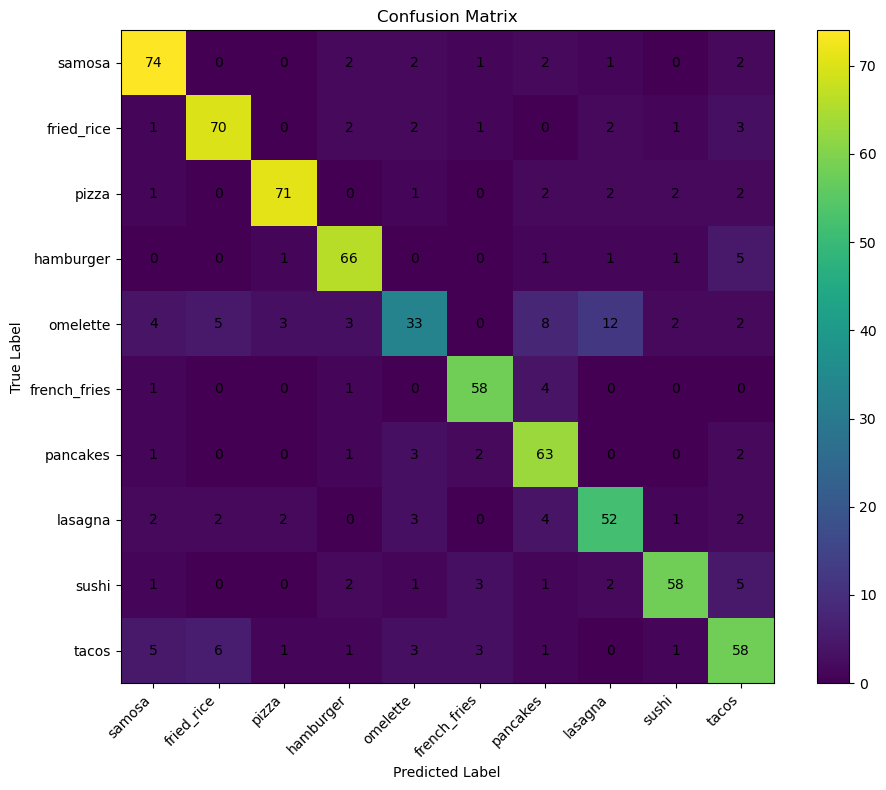

In [121]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(selected_classes)),
    selected_classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(selected_classes)),
    selected_classes
)

plt.colorbar()

for i in range(len(selected_classes)):
    for j in range(len(selected_classes)):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [122]:
from PIL import Image
import numpy as np
import tensorflow as tf

In [123]:
best_model = tf.keras.models.load_model(
    "food_classifier_frozen_best.keras"
)

In [124]:
def predict_food(image_path):

    image = Image.open(image_path).convert("RGB")

    image_resized = image.resize((224, 224))

    image_array = np.array(
        image_resized,
        dtype=np.float32
    )

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    image_array = tf.keras.applications.mobilenet_v2.preprocess_input(
        image_array
    )

    predictions = best_model.predict(
        image_array,
        verbose=0
    )

    predicted_index = np.argmax(predictions[0])

    predicted_food = selected_classes[predicted_index]

    confidence = predictions[0][predicted_index] * 100

    print("================================")
    print("       FOOD PREDICTION")
    print("================================")
    print("Food:", predicted_food)
    print("Confidence:", f"{confidence:.2f}%")
    print("================================")

In [126]:
image_path = r"D:\Downloads\images (13).jpeg"

predict_food(image_path)

       FOOD PREDICTION
Food: pizza
Confidence: 97.50%


In [127]:
image_path = r"D:\Downloads\images (12).jpeg"

predict_food(image_path)

       FOOD PREDICTION
Food: lasagna
Confidence: 81.24%


In [128]:
import pandas as pd

nutrition_data = {
    "food": [
        "samosa",
        "fried_rice",
        "pizza",
        "hamburger",
        "omelette",
        "french_fries",
        "pancakes",
        "lasagna",
        "sushi",
        "tacos"
    ],
    "calories": [262, 163, 266, 295, 154, 312, 227, 135, 130, 226],
    "protein": [5.0, 3.0, 11.0, 17.0, 11.0, 3.4, 6.0, 7.0, 6.0, 9.0],
    "carbs": [32.0, 25.0, 33.0, 24.0, 1.0, 41.0, 28.0, 18.0, 28.0, 18.0],
    "fat": [12.0, 6.0, 10.0, 18.0, 11.0, 15.0, 9.0, 5.0, 1.0, 12.0]
}

nutrition_df = pd.DataFrame(nutrition_data)

nutrition_df

,food,calories,protein,carbs,fat
0,samosa,262,5.0,32.0,12.0
1,fried_rice,163,3.0,25.0,6.0
2,pizza,266,11.0,33.0,10.0
3,hamburger,295,17.0,24.0,18.0
4,omelette,154,11.0,1.0,11.0
5,french_fries,312,3.4,41.0,15.0
6,pancakes,227,6.0,28.0,9.0
7,lasagna,135,7.0,18.0,5.0
8,sushi,130,6.0,28.0,1.0
9,tacos,226,9.0,18.0,12.0


In [129]:
def predict_food_with_nutrition(image_path):

    image = Image.open(image_path).convert("RGB")
    image_resized = image.resize((224, 224))

    image_array = np.array(
        image_resized,
        dtype=np.float32
    )

    image_array = np.expand_dims(image_array, axis=0)

    image_array = tf.keras.applications.mobilenet_v2.preprocess_input(
        image_array
    )

    predictions = best_model.predict(
        image_array,
        verbose=0
    )

    predicted_index = np.argmax(predictions[0])
    predicted_food = selected_classes[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    food_info = nutrition_df[
        nutrition_df["food"] == predicted_food
    ].iloc[0]

    print("================================")
    print("       FOOD PREDICTION")
    print("================================")
    print("Food:", predicted_food)
    print("Confidence:", f"{confidence:.2f}%")

    print("\nNutrition:")
    print("Calories:", food_info["calories"], "kcal")
    print("Protein:", food_info["protein"], "g")
    print("Carbohydrates:", food_info["carbs"], "g")
    print("Fat:", food_info["fat"], "g")
    print("================================")

In [133]:
image_path = r"D:\Downloads\images (13).jpeg"

predict_food(image_path)

       FOOD PREDICTION
Food: pizza
Confidence: 97.50%


In [134]:
import pandas as pd
from datetime import datetime
import os

if os.path.exists("meal_log.csv"):
    meal_log = pd.read_csv("meal_log.csv")
else:
    meal_log = pd.DataFrame(columns=[
        "date",
        "time",
        "meal_type",
        "food",
        "confidence",
        "calories",
        "protein",
        "carbs",
        "fat"
    ])

print("Meal log ready!")
print(meal_log)

Meal log ready!
Empty DataFrame
Columns: [date, time, meal_type, food, confidence, calories, protein, carbs, fat]
Index: []


In [135]:
def add_meal(food, confidence, meal_type):

    global meal_log

    food_info = nutrition_df[
        nutrition_df["food"] == food
    ]

    if food_info.empty:
        print("Food not found in nutrition database.")
        return

    food_info = food_info.iloc[0]

    now = datetime.now()

    new_meal = {
        "date": now.strftime("%Y-%m-%d"),
        "time": now.strftime("%H:%M:%S"),
        "meal_type": meal_type,
        "food": food,
        "confidence": round(float(confidence), 2),
        "calories": food_info["calories"],
        "protein": food_info["protein"],
        "carbs": food_info["carbs"],
        "fat": food_info["fat"]
    }

    meal_log = pd.concat(
        [meal_log, pd.DataFrame([new_meal])],
        ignore_index=True
    )

    meal_log.to_csv(
        "meal_log.csv",
        index=False
    )

    print("================================")
    print("       MEAL SAVED")
    print("================================")
    print("Food:", food)
    print("Meal Type:", meal_type)
    print("Confidence:", f"{confidence:.2f}%")
    print("Calories:", food_info["calories"], "kcal")
    print("Protein:", food_info["protein"], "g")
    print("Carbs:", food_info["carbs"], "g")
    print("Fat:", food_info["fat"], "g")
    print("================================")

In [136]:
add_meal(
    food="pizza",
    confidence=97.50,
    meal_type="Lunch"
)

       MEAL SAVED
Food: pizza
Meal Type: Lunch
Confidence: 97.50%
Calories: 266 kcal
Protein: 11.0 g
Carbs: 33.0 g
Fat: 10.0 g


C:\Users\ravik\AppData\Local\Temp\ipykernel_2952\124589994.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  meal_log = pd.concat(


In [137]:
print(meal_log)

         date      time meal_type   food  confidence calories  protein  carbs  \
0  2026-09-22  23:53:05     Lunch  pizza        97.5      266     11.0   33.0   

    fat  
0  10.0  


In [138]:
meal_log[
    [
        "date",
        "time",
        "meal_type",
        "food",
        "confidence",
        "calories",
        "protein",
        "carbs",
        "fat"
    ]
]

,date,time,meal_type,food,confidence,calories,protein,carbs,fat
0,2026-09-22,23:53:05,Lunch,pizza,97.5,266,11.0,33.0,10.0


In [139]:
from datetime import datetime

def daily_report():

    today = datetime.now().strftime("%Y-%m-%d")

    today_meals = meal_log[
        meal_log["date"] == today
    ]

    if today_meals.empty:
        print("No meals recorded today.")
        return

    total_calories = today_meals["calories"].sum()
    total_protein = today_meals["protein"].sum()
    total_carbs = today_meals["carbs"].sum()
    total_fat = today_meals["fat"].sum()

    print("\n======================================")
    print("        DAILY NUTRITION REPORT")
    print("======================================")

    print("Date:", today)
    print("Total Meals:", len(today_meals))

    print("\nNUTRITION TOTALS")
    print("--------------------------------------")
    print(f"Calories       : {total_calories:.1f} kcal")
    print(f"Protein        : {total_protein:.1f} g")
    print(f"Carbohydrates  : {total_carbs:.1f} g")
    print(f"Fat            : {total_fat:.1f} g")

    print("\nMEAL RECORDS")
    print("--------------------------------------")

    print(
        today_meals[
            ["time", "meal_type", "food", "calories"]
        ].to_string(index=False)
    )

    print("======================================")

In [140]:
daily_report()


        DAILY NUTRITION REPORT
Date: 2026-09-22
Total Meals: 1

NUTRITION TOTALS
--------------------------------------
Calories       : 266.0 kcal
Protein        : 11.0 g
Carbohydrates  : 33.0 g
Fat            : 10.0 g

MEAL RECORDS
--------------------------------------
    time meal_type  food calories
23:53:05     Lunch pizza      266


In [141]:
add_meal(
    food="samosa",
    confidence=85.20,
    meal_type="Evening Snack"
)

       MEAL SAVED
Food: samosa
Meal Type: Evening Snack
Confidence: 85.20%
Calories: 262 kcal
Protein: 5.0 g
Carbs: 32.0 g
Fat: 12.0 g


In [142]:
daily_report()


        DAILY NUTRITION REPORT
Date: 2026-09-22
Total Meals: 2

NUTRITION TOTALS
--------------------------------------
Calories       : 528.0 kcal
Protein        : 16.0 g
Carbohydrates  : 65.0 g
Fat            : 22.0 g

MEAL RECORDS
--------------------------------------
    time     meal_type   food calories
23:53:05         Lunch  pizza      266
23:54:35 Evening Snack samosa      262


In [143]:
import matplotlib.pyplot as plt
from datetime import datetime

def nutrition_graph():

    today = datetime.now().strftime("%Y-%m-%d")

    today_meals = meal_log[
        meal_log["date"] == today
    ]

    if today_meals.empty:
        print("No meals recorded today.")
        return

    total_calories = today_meals["calories"].sum()
    total_protein = today_meals["protein"].sum()
    total_carbs = today_meals["carbs"].sum()
    total_fat = today_meals["fat"].sum()

    labels = [
        "Calories",
        "Protein",
        "Carbs",
        "Fat"
    ]

    values = [
        total_calories,
        total_protein,
        total_carbs,
        total_fat
    ]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values)

    plt.title("Daily Nutrition Summary")
    plt.xlabel("Nutrition")
    plt.ylabel("Total Amount")

    plt.tight_layout()
    plt.show()

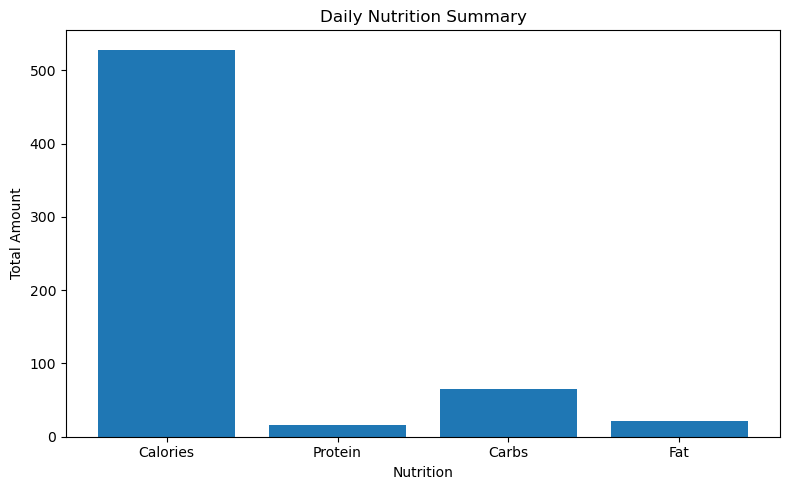

In [144]:
nutrition_graph()

In [145]:
%pip install streamlit

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.1
    Uninstalling protobuf-7.35.1:
      Successfully uninstalled protobuf-7.35.1
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.


In [146]:
import os

print("Notebook work saved.")
print(
    "Best model exists:",
    os.path.exists("food_classifier_frozen_best.keras")
)

Notebook work saved.
Best model exists: True


In [147]:
import os

print(os.path.exists("food_classifier_frozen_best.keras"))

True


In [148]:
http://localhost:8888/tree

SyntaxError: invalid syntax (114804411.py, line 1)

In [149]:
import os

print(os.path.exists("models/food_classifier_frozen_best.keras"))

True
